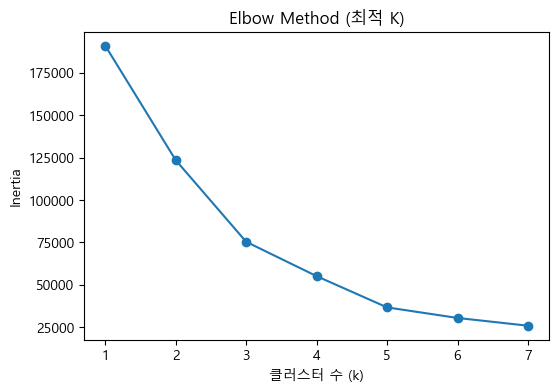


[클러스터별 평균 Recency & Monetary]
            Recency    Monetary
Cluster                        
0        147.777542  152.925895
1        147.719486   73.750673
2        410.774047   95.450163

[Cluster 0 예시]
                         customer_id     Recency  Monetary  Cluster
3   0000f6ccb0745a6a4b88665a16c9f078  176.223425    145.17        0
4   0004aac84e0df4da2b147fca70cf8255  176.223425    126.15        0
7   00053a61a98854899e70ed204dd4bafe  176.223425    166.63        0
11  00082cbe03e478190aadbea78542e933  176.223425    187.09        0
12  00090324bbad0e9342388303bb71ba0a  176.223425    143.17        0

[Cluster 1 예시]
                        customer_id     Recency  Monetary  Cluster
0  0000366f3b9a7992bf8c76cfdf3221e2   82.000000     74.17        1
1  0000b849f77a49e4a4ce2b2a4ca5be3f   85.000000     65.90        1
2  0000f46a3911fa3c0805444483337064  176.223425     77.34        1
5  0004bd2a26a76fe21f786e4fbd80607f  176.223425     59.11        1
6  00050ab1314c0e55a6ca13cf7181fec

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
df = pd.read_csv("marketing_advanced.csv", encoding="EUC-KR")
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['total_payment'] = df['price'] + df['shipping_charges']
rfm_rm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (df['order_purchase_timestamp'].max() - x.max()).days,
    'total_payment': 'sum'
}).reset_index()
rfm_rm.columns = ['customer_id', 'Recency', 'Monetary']
# 결측치를 평균으로 채움
rfm_rm['Recency'] = rfm_rm['Recency'].fillna(rfm_rm['Recency'].mean())
rfm_rm['Monetary'] = rfm_rm['Monetary'].fillna(rfm_rm['Monetary'].mean())
scaler = StandardScaler()
rm_scaled = scaler.fit_transform(rfm_rm[['Recency', 'Monetary']])
inertia = []
K = range(1, 8)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rm_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(6, 4))
plt.plot(K, inertia, 'o-')
plt.title('Elbow Method (최적 K)')
plt.xlabel('클러스터 수 (k)')
plt.ylabel('Inertia')
plt.show()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_rm['Cluster'] = kmeans.fit_predict(rm_scaled)
print("\n[클러스터별 평균 Recency & Monetary]")
print(rfm_rm.groupby('Cluster')[['Recency', 'Monetary']].mean())
df0 = rfm_rm[rfm_rm['Cluster'] == 0]
df1 = rfm_rm[rfm_rm['Cluster'] == 1]
df2 = rfm_rm[rfm_rm['Cluster'] == 2]
print("\n[Cluster 0 예시]")
print(df0.head())
print("\n[Cluster 1 예시]")
print(df1.head())
print("\n[Cluster 2 예시]")
print(df2.head())

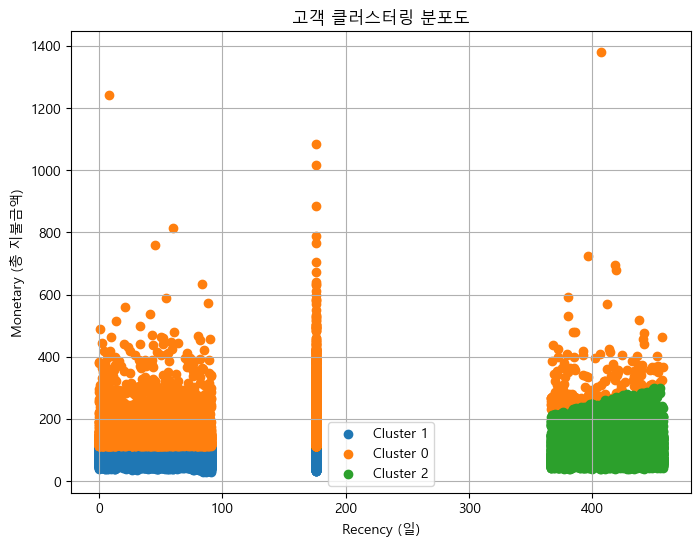

In [73]:
plt.figure(figsize=(8, 6))
for c in rfm_rm['Cluster'].unique():
    cluster_data = rfm_rm[rfm_rm['Cluster'] == c]
    plt.scatter(cluster_data['Recency'], cluster_data['Monetary'], label=f'Cluster {c}')
plt.xlabel('Recency (일)')
plt.ylabel('Monetary (총 지불금액)')
plt.title('고객 클러스터링 분포도')
plt.legend()
plt.grid(True)
plt.show()


In [74]:
print(rfm_rm['Cluster'].value_counts())


Cluster
1    60772
0    24313
2    10334
Name: count, dtype: int64


In [75]:
rfm_full = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (df['order_purchase_timestamp'].max() - x.max()).days,
    'order_id': 'nunique',
    'total_payment': 'sum'
}).reset_index()
rfm_full.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']


이탈고객이랑 기존 열 합치기

In [76]:
# Cluster 2 고객 ID 목록
cluster2_customers = df2['customer_id']

# 원본 df에서 Cluster 2 고객만 추출
df_cluster2 = df[df['customer_id'].isin(cluster2_customers)].copy()
df_cluster2

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,age,gender,country,payment_type,payment_installments,seller_id,shipping_charges,category1,category2,price,delivery_delay_days,approval_delay_minutes,weight_kg,volume_cm3,review_score,marketing_info_agree,agegroup,product_id,total_payment
11,6681163e3dab91c549952b2845b20281,0006fdc98a402fceb4eb0ee528f6a8d4,delivered,2023-12-18 09:19:00,2023-12-18 11:04,2024-01-03 18:42,2024-01-15,57,여성,핀란드,credit_card,2,d2374cbcbb3ca4ab1086534108cc3ab7,15,식품,가공식품,67.66,-12.0,7.0,5,15408.73,2,n,50대,d36740e054b84215,82.66
27,57caee5837cc4a8f605f3a83bff208db,0010a452c6d13139e50b57f19f52e04e,delivered,2023-12-11 09:50:00,2023-12-11 12:02,2023-12-26 10:44,2024-01-14,17,여성,한국,credit_card,10,7dc8c42cc750eeafea6c85712ffee9bf,26,화장품,스킨케어,40.05,-19.0,8.0,5,95738.10,3,n,10대,bab0e7dd64ab4c3f,66.05
32,58d34816de3da57e9e07d7b34aced1b8,0011857aff0e5871ce5eb429f21cdaf5,delivered,2023-11-28 07:16:00,2023-11-28 9:43,2023-12-06 17:11,2023-12-26,49,여성,중국,credit_card,3,9d5a9018aee56acb367ba9c3f05d1d6a,18,스포츠용품,등산,39.94,-20.0,7.0,5,93905.96,2,n,40대,fdc97c48e8704ecd,57.94
47,b46c295d27c87441788cfd92b75b1a3d,001a2bf0e46c684031af91fb2bce149d,delivered,2023-11-29 06:23:00,2023-11-29 8:56,2023-12-03 8:26,2023-12-21,36,여성,중국,credit_card,1,8b28d096634035667e8263d57ba3368c,11,스포츠용품,낚세,48.26,-18.0,12.0,5,94198.36,2,y,30대,08473b6a9bd24eec,59.26
74,b14a8291157869f3d51b2d24c96d2da7,002d71b244beb91ca7030b15ab526446,delivered,2023-10-22 15:11:00,2023-10-22 16:40,2023-11-01 14:58,2023-11-13,44,여성,태국,wallet,1,669ae81880e08f269a64487cfb287169,15,스포츠용품,낚세,47.78,-12.0,1726.0,5,80017.52,3,n,40대,08473b6a9bd24eec,62.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104854,bb411f818d648fd911d5c0d473ebcf19,ffe4c3aa14d4702fb11fe5b3c4dd755c,delivered,2023-10-25 12:57:00,2023-10-25 14:16,2023-11-06 11:17,2023-11-21,42,남성,중국,credit_card,1,01fdefa7697d26ad920e9e0346d4bd1b,18,가구,책상/책장,137.28,-15.0,12.0,25,131155.25,3,y,40대,e76df3f8cf074304,155.28
104859,b9017cb1a567f916deb91b09e54947ba,ffe7752edcf14b5819058b1948e02f3a,delivered,2023-11-13 06:43:00,2023-11-13 8:57,2023-11-22 13:02,2023-12-14,56,여성,브라질,credit_card,3,d98eec89afa3380e14463da2aabaea72,21,가구,침대,129.71,-22.0,17.0,0,161999.93,4,y,50대,7edaf494ceef4dee,150.71
104862,b497a58303bca7160ad663bd22cea268,ffe9102bb78a76921ba0ff3c4659616a,delivered,2023-11-09 08:55:00,2023-11-09 11:29,2023-11-19 19:41,2023-12-10,36,여성,덴마크,debit_card,1,d03698c2efd04a549382afa6623e27fb,31,가구,책상/책장,137.28,-21.0,65.0,1,178407.32,3,y,30대,e76df3f8cf074304,168.28
104877,c8126206d94637a4e63af00f4181a14d,ffef0ffa736c7b3d9af741611089729b,delivered,2023-10-29 14:04:00,2023-10-29 17:00,2023-11-07 14:41,2023-11-29,35,여성,호주,credit_card,1,c3cfdc648177fdbbbb35635a37472c53,29,스포츠용품,캠핑,42.70,-22.0,15.0,5,112381.40,2,y,30대,4e3c726f56f94f5b,71.70


describe

In [77]:
pd.set_option('display.max_columns', None)
display(df_cluster2.describe(include='all'))


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,age,gender,country,payment_type,payment_installments,seller_id,shipping_charges,category1,category2,price,delivery_delay_days,approval_delay_minutes,weight_kg,volume_cm3,review_score,marketing_info_agree,agegroup,product_id,total_payment
count,11377,11377,11377,11099,11377,11076,11377,11377.000000,11377,11377,11377,11377.000000,11377,11377.000000,11377,11377,11377.000000,11076.000000,11377.000000,11377.000000,11377.000000,11377.000000,11377,11377,11377,11377.000000
unique,10792,10334,5,NaN,10741,8771,239,NaN,2,28,4,NaN,937,NaN,6,37,NaN,NaN,NaN,NaN,NaN,NaN,2,5,37,NaN
top,332c6742772f2df936696b6512b10edb,0ac10a57d07e3d38b11f66283c44672b,delivered,NaN,2023-11-05 21:07,2023-12-28 18:55,2024-01-11,NaN,여성,중국,credit_card,NaN,4a3ca9315b744ce9f8e9374361493884,NaN,식품,건강식품,NaN,NaN,NaN,NaN,NaN,NaN,y,50대,d2e1b02d25294e6f,NaN
freq,4,4,11077,NaN,4,7,227,NaN,7191,1854,8459,NaN,369,NaN,3021,1023,NaN,NaN,NaN,NaN,NaN,NaN,7705,3606,1023,NaN
mean,NaN,NaN,NaN,2023-11-16 14:18:52.620956928,NaN,NaN,NaN,40.611585,NaN,NaN,NaN,3.270106,NaN,18.308078,NaN,NaN,68.391578,-12.860870,575.724971,4.433682,87116.394976,3.322669,NaN,NaN,NaN,86.699655
min,NaN,NaN,NaN,2023-10-01 01:36:00,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,NaN,NaN,28.080000,-71.000000,0.000000,0.000000,2000.000000,1.000000,NaN,NaN,NaN,32.900000
25%,NaN,NaN,NaN,2023-10-23 13:03:00,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,1.000000,NaN,13.000000,NaN,NaN,44.060000,-17.000000,12.000000,1.000000,26366.560000,3.000000,NaN,NaN,NaN,61.100000
50%,NaN,NaN,NaN,2023-11-15 09:17:00,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,2.000000,NaN,15.000000,NaN,NaN,60.460000,-13.000000,15.000000,5.000000,56062.680000,3.000000,NaN,NaN,NaN,80.020000
75%,NaN,NaN,NaN,2023-12-11 14:06:00,NaN,NaN,NaN,53.000000,NaN,NaN,NaN,5.000000,NaN,19.000000,NaN,NaN,83.160000,-9.000000,890.000000,5.000000,119709.070000,4.000000,NaN,NaN,NaN,107.760000
max,NaN,NaN,NaN,2023-12-31 23:09:00,NaN,NaN,NaN,64.000000,NaN,NaN,NaN,18.000000,NaN,186.000000,NaN,NaN,143.570000,161.000000,19172.000000,25.000000,500000.000000,5.000000,NaN,NaN,NaN,278.650000


 주문 수 (Frequency)

In [78]:
order_counts = df_cluster2.groupby('customer_id')['order_id'].nunique()
print("고객당 평균 주문 수:", order_counts.mean())


고객당 평균 주문 수: 1.0443197213083026


 주요 상품 카테고리 분석
 

In [79]:
top_categories = df_cluster2['category1'].value_counts().head(10)
print("주요 구매 카테고리:")
print(top_categories)


주요 구매 카테고리:
category1
식품       3021
의류       2360
전자제품     2001
스포츠용품    1989
화장품      1305
가구        701
Name: count, dtype: int64


구매일 히스토그램

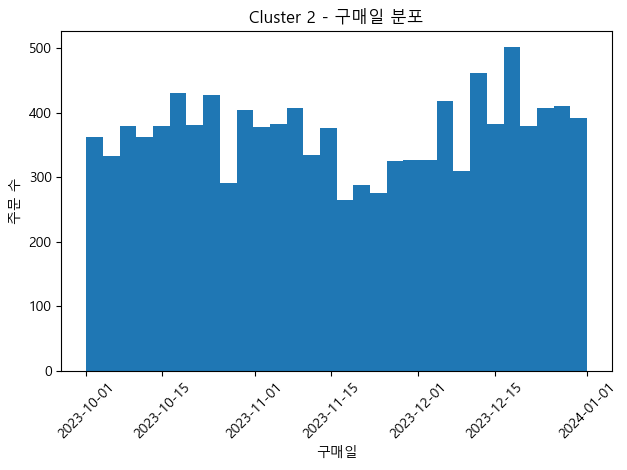

In [81]:
plt.hist(df_cluster2['order_purchase_timestamp'], bins=30)
plt.title('Cluster 2 - 구매일 분포')
plt.xlabel('구매일')
plt.ylabel('주문 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


리뷰점수 히스토그램

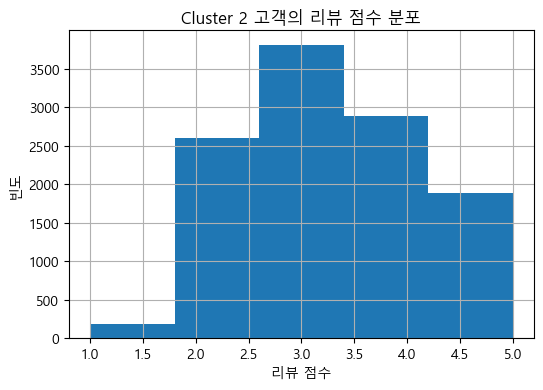

평균 리뷰 점수: 3.322668541794849


In [82]:
plt.figure(figsize=(6, 4))
df_cluster2['review_score'].hist(bins=5)
plt.title("Cluster 2 고객의 리뷰 점수 분포")
plt.xlabel("리뷰 점수")
plt.ylabel("빈도")
plt.show()

print("평균 리뷰 점수:", df_cluster2['review_score'].mean())


마케팅 정보활용 동의 비율

In [83]:
# 마케팅 수신 동의 비율 계산
marketing_rate = df_cluster2['marketing_info_agree'].value_counts(normalize=True) * 100
print("마케팅 정보 활용 동의 비율(%)")
print(marketing_rate)


마케팅 정보 활용 동의 비율(%)
marketing_info_agree
y    67.724356
n    32.275644
Name: proportion, dtype: float64


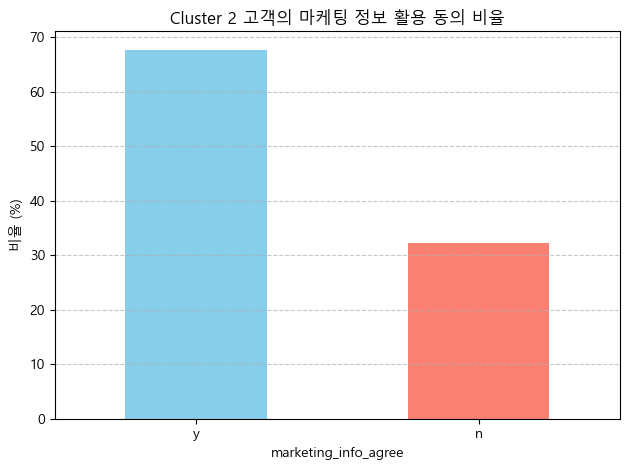

In [84]:
marketing_rate.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Cluster 2 고객의 마케팅 정보 활용 동의 비율')
plt.ylabel('비율 (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


이탈고객 성비

In [85]:
# 성별 분포 비교
df['Cluster'] = rfm_rm.set_index('customer_id').loc[df['customer_id']]['Cluster'].values
cluster2_gender = df[df['Cluster'] == 2]['gender'].value_counts(normalize=True)
cluster0_gender = df[df['Cluster'] == 0]['gender'].value_counts(normalize=True)
print("Cluster 2 vs Cluster 0 성별 분포 비교")
print(cluster2_gender, "\n", cluster0_gender)


Cluster 2 vs Cluster 0 성별 분포 비교
gender
여성    0.632065
남성    0.367935
Name: proportion, dtype: float64 
 gender
여성    0.629732
남성    0.370268
Name: proportion, dtype: float64


In [86]:
# 평균 배송비와 평균 가격 계산
avg_shipping = df_cluster2['shipping_charges'].mean()
avg_price = df_cluster2['price'].mean()

# 전체 평균 결제 금액
avg_total_payment = avg_shipping + avg_price

# 배송비 비율 계산 (%)
shipping_ratio = (avg_shipping / avg_total_payment) * 100

# 결과 출력
print(f"📦 평균 배송비: {avg_shipping:.2f} 달러")
print(f"🛒 평균 상품 가격: {avg_price:.2f} 달러")
print(f"💰 평균 총 결제 금액: {avg_total_payment:.2f} 달러")
print(f"🚚 배송비 비율: {shipping_ratio:.2f}%")


📦 평균 배송비: 18.31 달러
🛒 평균 상품 가격: 68.39 달러
💰 평균 총 결제 금액: 86.70 달러
🚚 배송비 비율: 21.12%


이탈고객 결제방식

In [87]:
df_cluster2['payment_type'].value_counts()

payment_type
credit_card    8459
wallet         2370
voucher         460
debit_card       88
Name: count, dtype: int64

이탈고객 국적?

In [94]:
df00_country = df_cluster2['country'].value_counts()
df00_country

country
중국       1854
한국       1309
괌         383
뉴질랜드      381
브라질       378
호주        377
캐나다       362
그리스       356
벨기에       352
스페인       338
영국        336
프랑스       332
핀란드       328
덴마크       326
스위스       323
폴란드       318
스웨덴       306
오스트리아     301
독일        300
이탈리아      294
태국        283
홍콩        275
파키스탄      270
베트남       267
싱가포르      263
말레이시아     260
일본        256
필리핀       249
Name: count, dtype: int64

이탈고객 연령대

In [95]:
age_group_counts = df_cluster2['agegroup'].value_counts().sort_index()
age_group_counts

agegroup
10대     761
20대    2308
30대    2324
40대    2378
50대    3606
Name: count, dtype: int64

이탈고객 

In [105]:
# 연령대 계산 (예: 20대, 30대, ...)
df_cluster2['age_group'] = (df_cluster2['age'] // 10) * 10
# 연령대별 고객 수
age_group_counts = df_cluster2['age_group'].value_counts().sort_index()

# 비율 계산 (%)
age_group_ratio = (age_group_counts / age_group_counts.sum()) * 100
age_group_ratio = age_group_ratio.round(2)

print("✅ Cluster 2 연령대 비율 (%)")
print(age_group_ratio)



✅ Cluster 2 연령대 비율 (%)
age_group
10     6.69
20    20.29
30    20.43
40    20.90
50    21.06
60    10.64
Name: count, dtype: float64


In [103]:
# 연령대별 성별 수 카운트
age_gender_counts = df_cluster2.groupby(['age_group', 'gender']).size().unstack(fill_value=0)

# 비율로 변환 (%)
age_gender_ratio = age_gender_counts.div(age_gender_counts.sum(axis=1), axis=0) * 100

# 결과 소수점 두 자리로 반올림
age_gender_ratio = age_gender_ratio.round(2)

print("✅ 연령대별 성비 비율 (%)")
print(age_gender_ratio)


✅ 연령대별 성비 비율 (%)
gender        남성     여성
age_group              
10         33.77  66.23
20         36.83  63.17
30         38.77  61.23
40         36.33  63.67
50         36.77  63.23
60         35.79  64.21


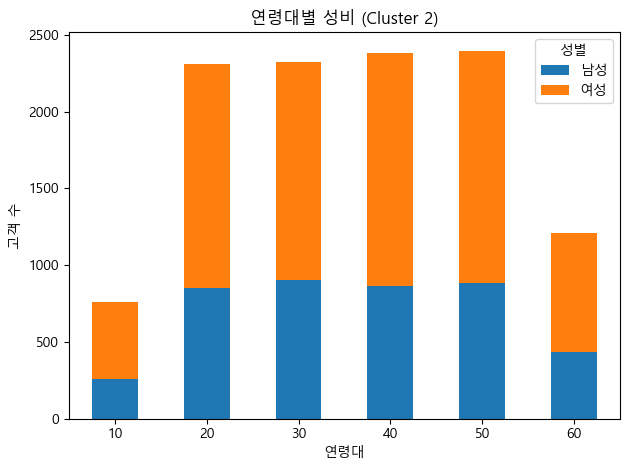

In [104]:
age_gender_counts.plot(kind='bar', stacked=True)
plt.title('연령대별 성비 (Cluster 2)')
plt.xlabel('연령대')
plt.ylabel('고객 수')
plt.xticks(rotation=0)
plt.legend(title='성별')
plt.tight_layout()
plt.show()


이탈고객 명단

In [93]:
df02 = df[df['customer_id'].isin(df_cluster2['customer_id'])]
df02

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,age,gender,country,payment_type,payment_installments,seller_id,shipping_charges,category1,category2,price,delivery_delay_days,approval_delay_minutes,weight_kg,volume_cm3,review_score,marketing_info_agree,agegroup,product_id,total_payment,Cluster
11,6681163e3dab91c549952b2845b20281,0006fdc98a402fceb4eb0ee528f6a8d4,delivered,2023-12-18 09:19:00,2023-12-18 11:04,2024-01-03 18:42,2024-01-15,57,여성,핀란드,credit_card,2,d2374cbcbb3ca4ab1086534108cc3ab7,15,식품,가공식품,67.66,-12.0,7.0,5,15408.73,2,n,50대,d36740e054b84215,82.66,2
27,57caee5837cc4a8f605f3a83bff208db,0010a452c6d13139e50b57f19f52e04e,delivered,2023-12-11 09:50:00,2023-12-11 12:02,2023-12-26 10:44,2024-01-14,17,여성,한국,credit_card,10,7dc8c42cc750eeafea6c85712ffee9bf,26,화장품,스킨케어,40.05,-19.0,8.0,5,95738.10,3,n,10대,bab0e7dd64ab4c3f,66.05,2
32,58d34816de3da57e9e07d7b34aced1b8,0011857aff0e5871ce5eb429f21cdaf5,delivered,2023-11-28 07:16:00,2023-11-28 9:43,2023-12-06 17:11,2023-12-26,49,여성,중국,credit_card,3,9d5a9018aee56acb367ba9c3f05d1d6a,18,스포츠용품,등산,39.94,-20.0,7.0,5,93905.96,2,n,40대,fdc97c48e8704ecd,57.94,2
47,b46c295d27c87441788cfd92b75b1a3d,001a2bf0e46c684031af91fb2bce149d,delivered,2023-11-29 06:23:00,2023-11-29 8:56,2023-12-03 8:26,2023-12-21,36,여성,중국,credit_card,1,8b28d096634035667e8263d57ba3368c,11,스포츠용품,낚세,48.26,-18.0,12.0,5,94198.36,2,y,30대,08473b6a9bd24eec,59.26,2
74,b14a8291157869f3d51b2d24c96d2da7,002d71b244beb91ca7030b15ab526446,delivered,2023-10-22 15:11:00,2023-10-22 16:40,2023-11-01 14:58,2023-11-13,44,여성,태국,wallet,1,669ae81880e08f269a64487cfb287169,15,스포츠용품,낚세,47.78,-12.0,1726.0,5,80017.52,3,n,40대,08473b6a9bd24eec,62.78,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104854,bb411f818d648fd911d5c0d473ebcf19,ffe4c3aa14d4702fb11fe5b3c4dd755c,delivered,2023-10-25 12:57:00,2023-10-25 14:16,2023-11-06 11:17,2023-11-21,42,남성,중국,credit_card,1,01fdefa7697d26ad920e9e0346d4bd1b,18,가구,책상/책장,137.28,-15.0,12.0,25,131155.25,3,y,40대,e76df3f8cf074304,155.28,2
104859,b9017cb1a567f916deb91b09e54947ba,ffe7752edcf14b5819058b1948e02f3a,delivered,2023-11-13 06:43:00,2023-11-13 8:57,2023-11-22 13:02,2023-12-14,56,여성,브라질,credit_card,3,d98eec89afa3380e14463da2aabaea72,21,가구,침대,129.71,-22.0,17.0,0,161999.93,4,y,50대,7edaf494ceef4dee,150.71,2
104862,b497a58303bca7160ad663bd22cea268,ffe9102bb78a76921ba0ff3c4659616a,delivered,2023-11-09 08:55:00,2023-11-09 11:29,2023-11-19 19:41,2023-12-10,36,여성,덴마크,debit_card,1,d03698c2efd04a549382afa6623e27fb,31,가구,책상/책장,137.28,-21.0,65.0,1,178407.32,3,y,30대,e76df3f8cf074304,168.28,2
104877,c8126206d94637a4e63af00f4181a14d,ffef0ffa736c7b3d9af741611089729b,delivered,2023-10-29 14:04:00,2023-10-29 17:00,2023-11-07 14:41,2023-11-29,35,여성,호주,credit_card,1,c3cfdc648177fdbbbb35635a37472c53,29,스포츠용품,캠핑,42.70,-22.0,15.0,5,112381.40,2,y,30대,4e3c726f56f94f5b,71.70,2


In [96]:
installment_count = df_cluster2[df_cluster2['payment_installments'] > 1]['order_id'].nunique()

# 전체 주문 건수
total_order_count = df_cluster2['order_id'].nunique()

# 비율 계산 (% 단위)
installment_ratio = (installment_count / total_order_count) * 100

print(f"할부 결제 비율: {installment_ratio:.2f}%")


할부 결제 비율: 57.33%
